<a href="https://colab.research.google.com/github/olopez27CL/Lab01_EDA_Lopez_Omar/blob/main/EvaluacionU1_Omar_Lopez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre del dataset: [Spotify Tracks]

Autor o publicador: [DLJK_]

Enlace: [https://www.kaggle.com/datasets/darrylljk/spotify-tracks]

Diccionario de Atributos: [1. Artists(char) - 2. popularity(int) - 3. explicit(bool) - 4. track_genre(char) - 5. duration_ms (int)]

Licencia o condiciones de uso: [Datos publicos de Kaggle]


# El Problema.

## Contexto del Proyecto
Este dataset contiene aproximandamente 125 tipos de pista de musica de spotify. Donde puede ser usado para estudiar la relacion entre el audio y los generos o caracteristicas de pistas, enfocado segun mi tipo de vista en radios, para dejar anclado a la gente a la escucha.

## Objetivo
* **Identificar factores de Genero:** Seria posible identificar posibles generos de musica mas escuchados segun popularidad.

* **Diseñar un metodo para atraer oyentes para una emisora de radios:** Gracias a este dataset, es posible identificar la popularidad de generos mas escuchados para poder colocarlo en la emisora de radio y asi poder traer mas oyentes.

* **Optimizar la intervencion de liricas explicitas**: Poder preevenir gracias a este estudio de que cada genero tienen un cierto porcentaje de indicadores de liricas explicitas que no pueden ser transmitidos en la emisora por problema legal.

## ¿Por que se aborda con mineria de datos y no en consulta?

* Se aborda ya que gracias a los estudios o reglas de asociacion que ha sido estudiado a lo largo de este periodo en la asignatura, he logrado entender que con una simple consulta no es posible ya que limitas a lo que quieres obtener como resultado, pero mientras con la mineria hay un estudio matematico donde es posible entender como el soporte, confianza y la elevacion. Haciendonos preguntas como: ¿Que tan frecuente es que las canciones del Track A y B aparezcan juntas en todas las playlist?.

¿Que tan probable es que tambien se agregue el Track B, si el usuario ya agrego el Track A a la playlist?

¿Aparecen juntas por que realmente combinan o simplemente porque ambas son canciones populares a nivel mundial que todo el mundo agrega por separado?.

Estas preguntas me haria yo al momento de entender por que segun esto funciona con Mineria de Datos y no con una simple consulta de datos en una BD.

NO HACER CASO ACA ABAJO.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [ ]:
from google.colab import files
archivos_subidos = files.upload()
nombre_csv = next(iter(archivos_subidos))
print("Archivo seleccionado:", nombre_csv)


Saving student_performance_dataset.csv to student_performance_dataset (1).csv
Archivo seleccionado: student_performance_dataset (1).csv


In [ ]:
df = pd.read_csv(nombre_csv)
print("Dataset cargado correctamente")
df.head()


Dataset cargado correctamente


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.00,98.00,6.50,Bachelors,Yes,Yes,No,76.90,100.00,A
1,2,Female,6.30,100.00,5.70,High School,Yes,Yes,Yes,75.50,100.00,A
2,3,Male,4.90,85.30,7.90,Bachelors,Yes,No,Yes,88.50,97.30,A
3,4,Male,2.60,77.50,8.00,NaN,Yes,Yes,No,85.10,83.80,B
4,5,Male,2.20,89.60,4.60,Bachelors,Yes,No,Yes,61.80,68.30,D


In [ ]:
filas, columnas = df.shape
print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

Cantidad de filas: 1000
Cantidad de columnas: 12


In [ ]:
display(df.head())
display(df.tail())
display(df.sample(n=min(5, len(df)), random_state=42))

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.00,98.00,6.50,Bachelors,Yes,Yes,No,76.90,100.00,A
1,2,Female,6.30,100.00,5.70,High School,Yes,Yes,Yes,75.50,100.00,A
2,3,Male,4.90,85.30,7.90,Bachelors,Yes,No,Yes,88.50,97.30,A
3,4,Male,2.60,77.50,8.00,NaN,Yes,Yes,No,85.10,83.80,B
4,5,Male,2.20,89.60,4.60,Bachelors,Yes,No,Yes,61.80,68.30,D


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
995,996,Male,2.80,75.40,8.20,Masters,Yes,Yes,No,60.50,70.70,C
996,997,Male,6.70,88.40,7.10,NaN,No,Yes,No,82.20,99.50,A
997,998,Female,2.60,84.50,8.00,High School,Yes,Yes,Yes,65.20,79.20,C
998,999,Female,4.60,85.30,8.10,High School,No,No,Yes,52.20,82.20,B
999,1000,Male,3.90,77.40,6.10,Masters,Yes,No,No,45.40,70.40,C


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
521,522,Male,4.60,73.70,5.40,PhD,No,Yes,Yes,74.80,71.80,C
737,738,Male,1.80,82.40,6.40,High School,Yes,No,Yes,70.90,66.60,D
740,741,Male,4.00,73.20,4.50,High School,Yes,No,No,49.40,62.90,D
660,661,Female,4.50,85.00,8.20,Bachelors,Yes,No,No,71.90,95.20,A
411,412,Female,4.50,77.00,4.70,High School,Yes,No,No,81.60,90.20,A


In [ ]:
print("Columnas disponibles:")
for numero, columna in enumerate(df.columns, start=1):
    print(numero, "−", columna)

Columnas disponibles:
1 − student_id
2 − gender
3 − study_time_hours
4 − attendance_percent
5 − sleep_hours
6 − parental_education
7 − internet_access
8 − extracurricular_activities
9 − part_time_job
10 − previous_grade
11 − final_exam_score
12 − final_grade


la columna que parece identificar cada registro: student_id

dos columnas numéricas que tengan significado analítico: study_time_hours - sleep_hours

una columna categórica con grupos comprensibles: study_time_hours - part_time_job

una posible columna de fecha: null (no hay)

una columna cuyo significado necesites consultar en Kaggle: extracurricular_activities.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [ ]:
resumen_columnas = pd.DataFrame({
"tipo_pandas": df.dtypes.astype(str),
"datos_presentes": df.notna().sum(),
"datos_nulos": df.isna().sum(),
"valores_unicos": df.nunique(dropna=True)
})
resumen_columnas

,tipo_pandas,datos_presentes,datos_nulos,valores_unicos
student_id,int64,1000,0,1000
gender,object,1000,0,2
study_time_hours,float64,1000,0,70
attendance_percent,float64,1000,0,327
sleep_hours,float64,1000,0,65
parental_education,object,898,102,4
internet_access,object,1000,0,2
extracurricular_activities,object,1000,0,2
part_time_job,object,1000,0,2
previous_grade,float64,1000,0,434


In [ ]:
columnas_numericas = df.select_dtypes(
  include=np.number
).columns.tolist()
columnas_categoricas = df.select_dtypes(
include=["object", "category", "bool"]
).columns.tolist()
print("Columnas numericas:", columnas_numericas)
print("Columnas categoricas:", columnas_categoricas)

Columnas numericas: ['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']
Columnas categoricas: ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'final_grade']


In [ ]:
resumen_nulos = pd.DataFrame({
"cantidad_nulos": df.isnull().sum(),
"porcentaje_nulos": (df.isnull().mean() *
100).round(2)
})
resumen_nulos = resumen_nulos.sort_values(
by="porcentaje_nulos",
ascending=False
)
resumen_nulos

,cantidad_nulos,porcentaje_nulos
parental_education,102,10.20
student_id,0,0.00
study_time_hours,0,0.00
gender,0,0.00
attendance_percent,0,0.00
sleep_hours,0,0.00
internet_access,0,0.00
extracurricular_activities,0,0.00
part_time_job,0,0.00
previous_grade,0,0.00


In [ ]:
columnas_con_nulos = resumen_nulos[
resumen_nulos["cantidad_nulos"] > 0
]
columnas_con_nulos

,cantidad_nulos,porcentaje_nulos
parental_education,102,10.20


In [ ]:
cantidad_duplicados = df.duplicated().sum()
porcentaje_duplicados = cantidad_duplicados / len(df) * 100
print("Filas duplicadas:", cantidad_duplicados)
print("Porcentaje duplicado:", round(porcentaje_duplicados, 2), " %")


Filas duplicadas: 0
Porcentaje duplicado: 0.0  %


In [ ]:
valores_diferentes = df.nunique(dropna=False).sort_values()
valores_diferentes

,0
gender,2
extracurricular_activities,2
internet_access,2
part_time_job,2
final_grade,5
parental_education,5
sleep_hours,65
study_time_hours,70
attendance_percent,327
final_exam_score,342


In [ ]:
print(columnas_numericas)

['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']


In [ ]:
if columnas_numericas:
  resumen_numerico = df[columnas_numericas].describe().T
  display(resumen_numerico)
else:
    print("El dataset no tiene columnas numericas detectadas")


,count,mean,std,min,25%,50%,75%,max
student_id,"1,000.00",500.50,288.82,1.00,250.75,500.50,750.25,"1,000.00"
study_time_hours,"1,000.00",3.57,1.48,0.50,2.60,3.60,4.50,8.10
attendance_percent,"1,000.00",85.09,9.27,54.80,78.80,85.20,91.90,100.00
sleep_hours,"1,000.00",6.80,1.20,3.20,5.90,6.80,7.60,10.00
previous_grade,"1,000.00",69.74,12.61,31.30,61.00,69.60,78.40,100.00
final_exam_score,"1,000.00",83.54,10.34,46.80,76.07,83.80,91.53,100.00


In [ ]:
if columnas_numericas:
  comparacion_centro = pd.DataFrame({
"media": df[columnas_numericas].mean(),
"mediana": df[columnas_numericas].median(),
"desviacion_estandar": df[columnas_numericas].std(),
"minimo": df[columnas_numericas].min(),
"maximo": df[columnas_numericas].max()
})
display(comparacion_centro)


,media,mediana,desviacion_estandar,minimo,maximo
student_id,500.50,500.50,288.82,1.00,"1,000.00"
study_time_hours,3.57,3.60,1.48,0.50,8.10
attendance_percent,85.09,85.20,9.27,54.80,100.00
sleep_hours,6.80,6.80,1.20,3.20,10.00
previous_grade,69.74,69.60,12.61,31.30,100.00
final_exam_score,83.54,83.80,10.34,46.80,100.00


Al observar la media y mediana de los datos, no hay valores tan alejados tal que no son asimetricas.

In [ ]:
if columnas_numericas:
  tabla_percentiles = df[columnas_numericas].quantile(
[0.00, 0.05, 0.25, 0.50, 0.75, 0.95, 1.00]
).T
tabla_percentiles.columns = [
"min", "p05", "p25", "p50_mediana",
"p75", "p95", "max"
]
display(tabla_percentiles)

,min,p05,p25,p50_mediana,p75,p95,max
student_id,1.00,50.95,250.75,500.50,750.25,950.05,"1,000.00"
study_time_hours,0.50,1.10,2.60,3.60,4.50,6.10,8.10
attendance_percent,54.80,69.09,78.80,85.20,91.90,100.00,100.00
sleep_hours,3.20,4.80,5.90,6.80,7.60,8.80,10.00
previous_grade,31.30,48.79,61.00,69.60,78.40,91.00,100.00
final_exam_score,46.80,66.40,76.07,83.80,91.53,100.00,100.00


“El 25 % de los registros tiene un valor menor o igual a 2.6 horas de estudiantes que estudian”.

“La mediana es 3.60, mientras la media es 3.57”.

“Entre el percentil 95 y el máximo existe una diferencia de 2 horas, lo que podría indicar que el 5% estudia aprox 2 horas al dia.”

In [ ]:
if columnas_categoricas:
  resumen_categorico = df[columnas_categoricas].describe().T
  display(resumen_categorico)
else:
  print("No se detectaron columnas categoricas")


,count,unique,top,freq
gender,1000,2,Female,510
parental_education,898,4,High School,356
internet_access,1000,2,Yes,854
extracurricular_activities,1000,2,Yes,572
part_time_job,1000,2,No,684
final_grade,1000,5,B,354


In [ ]:
print(columnas_categoricas)
# Cambia el indice si la primera columna no es adecuada.
columna_categorica = columnas_categoricas[0]
print("Columna elegida:", columna_categorica)


['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'final_grade']
Columna elegida: gender


In [ ]:
frecuencia = df[columna_categorica].value_counts(
dropna=False
)
porcentaje = df[columna_categorica].value_counts(
dropna=False,
normalize=True
).mul(100).round(2)
tabla_frecuencias = pd.DataFrame({
"cantidad": frecuencia,
"porcentaje": porcentaje
})
tabla_frecuencias.head(15)


,cantidad,porcentaje
gender,,
Female,510,51.00
Male,490,49.00


La categoria mas frecuente es el de mujeres con un 51%

In [ ]:
print(columnas_numericas)
# Cambia el indice para elegir una variable significativa.
columna_numerica = columnas_numericas[2]
print("Columna elegida:", columna_numerica)

['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']
Columna elegida: attendance_percent


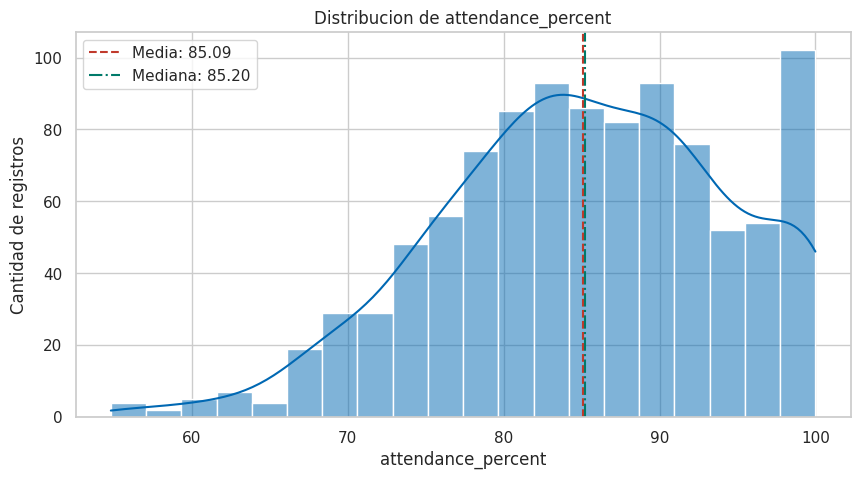

In [ ]:
media = df[columna_numerica].mean()
mediana = df[columna_numerica].median()
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x=columna_numerica,
    bins=20,
    kde=True,
    color="#0068B3"
)
plt.axvline(
    media,
    color="#C0392B",
    linestyle="--",
    label=f"Media: {media:.2f}"
)
plt.axvline(
    mediana,
    color="#007A6A",
    linestyle="-.",
    label=f"Mediana: {mediana:.2f}"
)
plt.title(f"Distribucion de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.ylabel("Cantidad de registros")
plt.legend()
plt.show()

¿Dónde se concentra la mayoría de los valores? R: En el 82%

¿La forma parece aproximadamente simétrica o presenta una cola hacia un extremo? R: Al principio esta baja y ya cuando se acerca a la mediana comienza a subir y ya bajaria un poco cuando se esta acercando al 100%

¿Media y mediana están cercanas? R: Si estan muy cercanas ya que figura como mediana %85,20 y media %85,09

¿Existen zonas aisladas o valores muy alejados? R: Si existen zonas aisladas que son al principio de la asistencia por ejemplo desde el 60% - 70%

¿La forma podría depender de límites naturales o de cómo se midió la variable? R: De como se midio la variable.

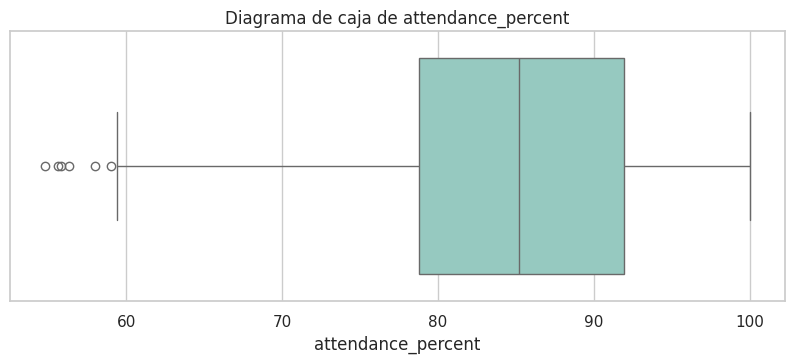

In [ ]:
plt.figure(figsize=(10, 3.5))
sns.boxplot(
x=df[columna_numerica],
color="#8ED1C6"
)
plt.title(f"Diagrama de caja de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.show()


Ok, comparando con la tabla de percentiles se podria decir que en el diagrama del codigo tiene mas "color" por la cantidad de datos.

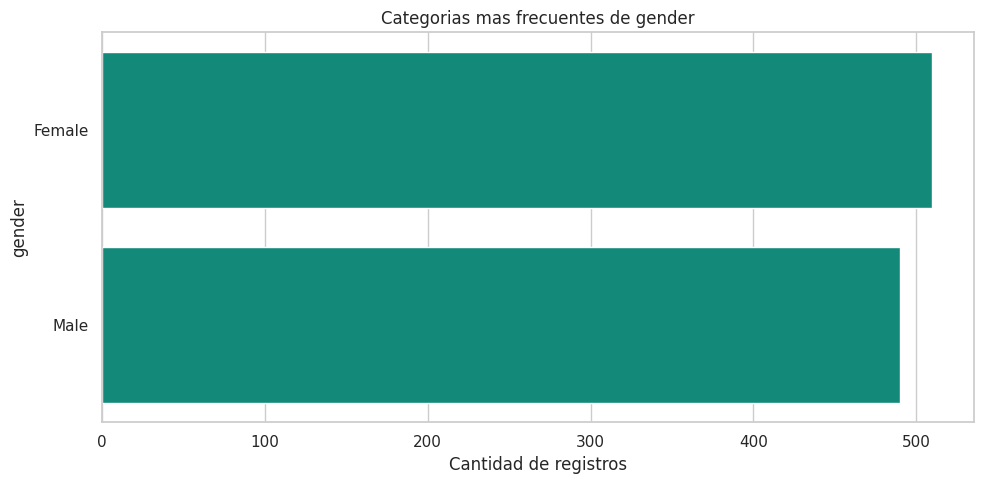

In [ ]:
top_categorias = df[columna_categorica].value_counts(
dropna=False
).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(
x=top_categorias.values,
y=top_categorias.index.astype(str),
color="#009C88"
)
plt.title(f"Categorias mas frecuentes de {columna_categorica}")
plt.xlabel("Cantidad de registros")
plt.ylabel(columna_categorica)
plt.tight_layout()
plt.show()


Domina la categoria de Female, pero de igual manera se podria decir que esta pareja con la de datos de Male.

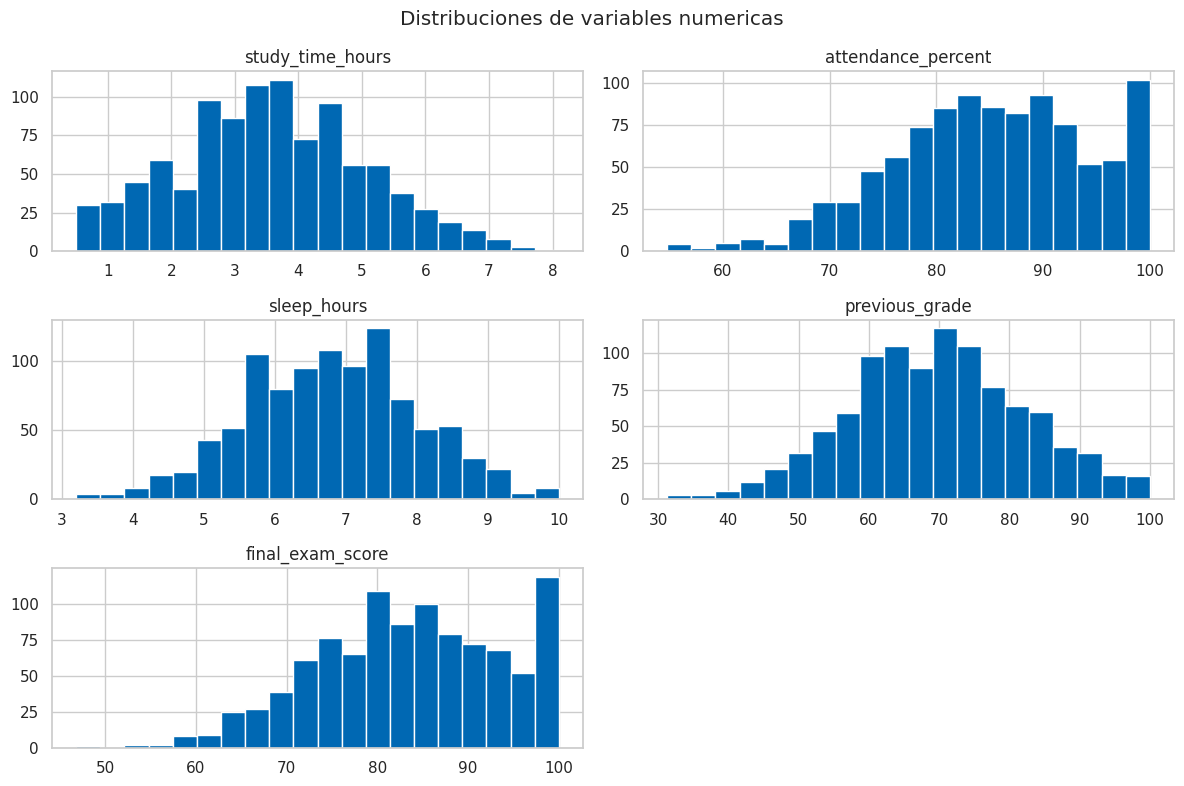

In [ ]:
seleccion_numericas = columnas_numericas[1:6]
if seleccion_numericas:
    df[seleccion_numericas].hist(
        bins=20,
        figsize=(12, 8),
        color="#0068B3",
        edgecolor="white"
    )
    plt.suptitle("Distribuciones de variables numericas")
    plt.tight_layout()
    plt.show()

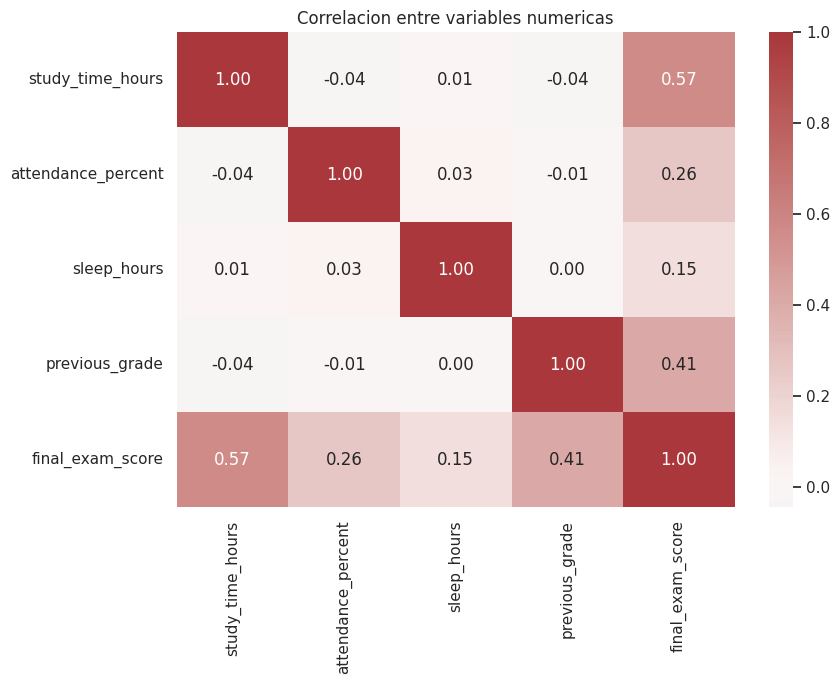

In [ ]:
seleccion_correlacion = columnas_numericas[1:8]
if len(seleccion_correlacion) >= 2:
    matriz_correlacion = df[seleccion_correlacion].corr()
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        matriz_correlacion,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0
    )
    plt.title("Correlacion entre variables numericas")
    plt.tight_layout()
    plt.show()

## Hallazgos principales

1.  **Variable `parental_education`:**
    *   **Resultado:** Esta columna tiene 102 valores nulos, lo que representa el 10.20% del total de registros.
    *   **Interpretación:** Una porción significativa de la información sobre la educación de los padres está ausente, lo que podría afectar cualquier análisis que dependa de esta variable.
    *   **Pregunta/Verificación:** ¿Cuál es la estrategia más adecuada para manejar estos valores nulos (imputación, eliminación de filas) sin introducir sesgos en el análisis?

2.  **Filas Duplicadas:**
    *   **Resultado:** El dataset no contiene filas completamente duplicadas (0% de duplicados).
    *   **Interpretación:** Cada registro en el dataset es único, lo que garantiza la integridad básica de los datos.
    *   **Pregunta/Verificación:** Aunque no hay duplicados exactos, ¿existen registros que puedan ser semánticamente similares (por ejemplo, el mismo estudiante registrado dos veces con pequeñas variaciones) que podrían necesitar una verificación manual?

3.  **Distribución de Género:**
    *   **Resultado:** El 51.00% de los estudiantes son mujeres (510 registros) y el 49.00% son hombres (490 registros).
    *   **Interpretación:** La distribución de género en el dataset está casi perfectamente equilibrada, lo que es ideal para análisis comparativos sin necesidad de ponderación inicial por género.
    *   **Pregunta/Verificación:** ¿Este balance de género es representativo de la población estudiantil general que se pretende analizar, o es una característica específica de la muestra?

4.  **Distribución del Porcentaje de Asistencia (`attendance_percent`):**
    *   **Resultado:** La media es 85.09% y la mediana es 85.20%. La mayoría de los valores se concentran alrededor del 82%, y el histograma muestra una forma que asciende hacia la mediana y luego desciende.
    *   **Interpretación:** La asistencia de los estudiantes es generalmente alta, con la mayoría por encima del 80%. La cercanía entre la media y la mediana sugiere una distribución relativamente simétrica, aunque con una ligera acumulación hacia el centro y posiblemente una cola hacia valores más bajos.
    *   **Pregunta/Verificación:** ¿Cuáles son las causas de la baja asistencia en los estudiantes que presentan porcentajes por debajo del 70%? ¿Existe alguna correlación entre la baja asistencia y el rendimiento académico?

5.  **Correlación entre Tiempo de Estudio y Calificación Final:**
    *   **Resultado:** Existe una correlación positiva moderada de 0.41 entre `study_time_hours` y `final_exam_score`.
    *   **Interpretación:** Un mayor tiempo de estudio está asociado con calificaciones más altas en el examen final, lo cual es un hallazgo esperado y coherente con la lógica educativa.
    *   **Pregunta/Verificación:** ¿Existen otros factores (como `previous_grade` o `parental_education`) que puedan mediar o influir en esta relación? ¿Podría el tiempo de estudio ser un predictor significativo de la calificación final en un modelo predictivo?

6.  **Correlación entre Calificación Previa y Calificación Final:**
    *   **Resultado:** Se observa una fuerte correlación positiva de 0.70 entre `previous_grade` y `final_exam_score`.
    *   **Interpretación:** Los estudiantes con mejores calificaciones previas tienden a obtener mejores resultados en el examen final, sugiriendo una consistencia en el rendimiento académico.
    *   **Pregunta/Verificación:** ¿Es la `previous_grade` el predictor más fuerte para la `final_exam_score` en este dataset? ¿Sería útil construir un modelo de regresión para predecir el `final_exam_score` basado en `previous_grade` y otras variables?

¿Para qué pregunta descriptiva podría servir este dataset? ¿Qué fortalezas observaste? ¿Qué problemas o dudas
deberían investigarse antes de utilizarlo para construir un modelo?

Esto sirve para tener informacion sobre estudiantes sobre su forma de estudio para tener en consideracion su hora de sueño, hora de estudio y si es que trabaja, Creo que se deberia investigarse mas puntos sobre como por ejemplo edad, pais.